# Importing Packages and Configuring
- from textbook

In [2]:
import pandas as pd
import numpy as np

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for better display in Jupyter
%matplotlib inline

# Set default figure size for all plots (width, height in inches)
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8, 5)  # Larger default size
matplotlib.rcParams['figure.dpi'] = 100          # Resolution
matplotlib.rcParams['font.size'] = 11            # Default font size


# Configure Seaborn style
sns.set_style("whitegrid")                       # Clean grid background
sns.set_palette("deep")                          # Colorblind-friendly palette
sns.set_context("notebook")                      # Appropriate scaling

#for geospacial plotting
import warnings
# Suppress all non-critical warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
import geopandas 
import folium
import geodatasets

# Data quality check / Loading

## Exploring Initial Data
*By Grace Gormley*

### Importing each dataset

In [3]:
#Making my divvy dataset from 2024-2025
import glob #gonna be honest, I got this from chat so I dont need to do it one by one (i'm combining each month from 12/25 to 1/24)

files = glob.glob("/Users/gracegormley/Desktop/Stat 303-1/project/divvy 2024-2025/*.csv")   # grabs all CSVs in the folder

dfs = []                                      # empty list to store DataFrames
for f in files:
    dfs.append(pd.read_csv(f))

divvy = pd.concat(dfs, ignore_index=True)

In [4]:
#make sure they're in chronological order
divvy["started_at"] = pd.to_datetime(divvy["started_at"], format="mixed")
divvy = divvy.sort_values(by="started_at")

In [5]:
#Importing my extra datasets
traffic = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/Chicago_Traffic_Tracker_-_Congestion_Estimates_by_Segments_20251125.csv')
bus_stops = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/CTA_BusStops_20251125.csv')
L_stops = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/CTA_-_System_Information_-_List_of_\'L\'_Stops_20251125.csv')
population = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/ACS_5_Year_Data_by_Community_Area.csv') #this isn't from chicago, since they organize pop by zip code. Someone already sorted them, so I'm using their data: https://www.kaggle.com/datasets/aniket0712/acs-5-year-data-by-community-area/code 
bike_stations = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/Divvy_Bicycle_Stations_20251201.csv')

### Taking a look at each dataset

In [6]:
#Printing the head of each dataset to get an idea of the contents

In [7]:
divvy.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
3486147,6A9D809ABDF70617,electric_bike,2024-01-01 00:00:39,2024-01-01 00:07:56,NaN,NaN,Clark St & Wrightwood Ave,TA1305000014,41.950000,-87.650000,41.929546,-87.643118,member
3491360,26B9F6E416A68EBA,electric_bike,2024-01-01 00:00:50,2024-01-01 00:04:20,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual
3486040,30EF016A0DF5ECEE,electric_bike,2024-01-01 00:00:52,2024-01-01 00:04:25,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual
3467452,0D9E85F804C85828,electric_bike,2024-01-01 00:00:53,2024-01-01 00:22:30,Clinton St & Madison St,TA1305000032,NaN,NaN,41.881909,-87.641296,41.890000,-87.620000,member
3410785,56F5C3ED5178C131,classic_bike,2024-01-01 00:01:01,2024-01-01 00:24:12,LaSalle St & Illinois St,13430,Indiana Ave & Roosevelt Rd,SL-005,41.890762,-87.631697,41.867888,-87.623041,member


In [8]:
traffic.head()

,SEGMENTID,STREET,DIRECTION,FROM_STREET,TO_STREET,LENGTH,STREET_HEADING,COMMENTS,START_LONGITUDE,START_LATITUDE,END_LONGITUDE,END_LATITUDE,CURRENT_SPEED,LAST_UPDATED
0,1284,Chicago,WB,Lake Shore Dr,Michigan,0.370000,E,NaN,-87.617048,41.896936,-87.624241,41.896835,-1,2011-08-10 00:00:00.0
1,951,Washington,WB,Kedzie,Schraeder,0.280000,W,NaN,-87.706169,41.882932,-87.711747,41.882818,-1,2010-07-21 14:51:00.0
2,750,Elston,SE,Milwaukee,Austin,0.330000,N,NaN,-87.783224,41.992665,-87.778073,41.989905,-1,2010-07-21 14:51:10.0
3,1164,Harlem,SB,Ogden,Pershing,0.173023,S,Outside City Limits,-87.802922,41.823751,-87.803025,41.821245,-1,2010-07-21 14:51:15.0
4,1122,127th,EB,Western,I-57 Expy,0.907892,W,Outside City Limits,-87.680077,41.662512,-87.662540,41.662850,-1,2010-07-21 14:51:06.0


In [9]:
bus_stops.tail(70)

,the_geom,SYSTEMSTOP,STREET,CROSS_ST,DIR,POS,ROUTESSTPG,OWLROUTES,CITY,PUBLIC_NAM
10690,POINT (-87.74481606799998 41.862335599000005),"10,258",CICERO,14TH STREET,SB,NS,54,NaN,CICERO,Cicero & 14th Street
10691,POINT (-87.628356 41.89926400000002),"5,375",STATE,DELAWARE,SB,NS,36,NaN,CHICAGO,State & Delaware
10692,POINT (-87.654837999 41.96342100099997),"1,050",SHERIDAN,SUNNYSIDE,SB,FS,151,NaN,CHICAGO,Sheridan & Sunnyside
10693,POINT (-87.68103544299998 41.828731903000005),"4,432",35TH/ARCHER,ORANGE LINE STATION,SWB,TERM,35,NaN,CHICAGO,35th/Archer Orange Line Station
10694,POINT (-87.5400057 41.65944309499997),"7,297",AVENUE O,130TH STREET,SB,NS,30,NaN,CHICAGO,Avenue O & 130th Street
...,...,...,...,...,...,...,...,...,...,...
10755,POINT (-87.69960900000001 42.02665914200003),"14,738",DODGE,OAKTON,SB,NS,93,NaN,EVANSTON,Dodge & Oakton
10756,POINT (-87.714284169 41.933375263000016),"5,563",MILWAUKEE,WISNER,NWB,NS,56,NaN,CHICAGO,Milwaukee & Wisner
10757,POINT (-87.81891211099997 42.00458322200001),"9,910",NORTHWEST HWY,OVERHILL,NWB,FS,68,NaN,CHICAGO,Northwest Hwy & Overhill
10758,POINT (-87.67733964000001 42.053723761000015),"17,295",SHERIDAN,FOSTER,SB,FS,201,NaN,EVANSTON,Sheridan & Foster


In [10]:
L_stops.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,Location
0,30162,W,18th (54th/Cermak-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
1,30161,E,18th (Loop-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
2,30022,N,35th/Archer (Loop-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
3,30023,S,35th/Archer (Midway-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
4,30213,N,35-Bronzeville-IIT (Harlem-bound),35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),41120,True,False,False,True,False,False,False,False,False,"(41.831677, -87.625826)"


In [11]:
population.head()

,ACS Year,Community Area,"Under $25,000","$25,000 to $49,999","$50,000 to $74,999","$75,000 to $125,000","$125,000 +",Male 0 to 17,Male 18 to 24,Male 25 to 34,...,White,Black or African American,American Indian or Alaska Native,Asian,Native Hawaiian or Pacific Islander,Other Race,Multiracial,White Not Hispanic or Latino,Hispanic or Latino,Record ID
0,2023,ALBANY PARK,1269,1916,1801,2306,3379,4799,2955,4513,...,21496,2228,759,7124,1,7888,8334,16115,21108,2023_ALBANY PARK
1,2023,ARCHER HEIGHTS,223,752,441,795,739,1927,732,1102,...,6232,10,108,679,0,3705,3142,2043,11097,2023_ARCHER HEIGHTS
2,2023,ARMOUR SQUARE,701,798,370,637,597,1300,487,871,...,2556,1487,107,8402,61,212,325,2226,565,2023_ARMOUR SQUARE
3,2023,ASHBURN,797,1351,1985,3014,2735,5150,1964,2881,...,11297,18124,697,436,0,7772,4517,3774,19917,2023_ASHBURN
4,2023,AUBURN GRESHAM,2541,2451,1592,2202,1850,5803,1836,2964,...,760,43414,119,399,0,993,798,491,1577,2023_AUBURN GRESHAM


In [12]:
bike_stations.head()

,ID,Station Name,Short Name,Total Docks,Docks in Service,Status,Latitude,Longitude,Location
0,1859717767703464460,Kedzie Ave & Redfield Dr,CHI01795,15,15,In Service,41.765230,-87.703160,POINT (-87.70316 41.76523)
1,1861588043429399408,McCormick Blvd & Devon Ave,CHI01881,11,11,In Service,41.997200,-87.711050,POINT (-87.71105 41.9972)
2,a3af1767-a135-11e9-9cda-0a87ae2ba916,Broadway & Granville Ave,CHI00563,23,23,In Service,41.994780,-87.660285,POINT (-87.6602845349 41.9947796884)
3,a3aa91f4-a135-11e9-9cda-0a87ae2ba916,Greenview Ave & Diversey Pkwy,CHI00382,15,15,In Service,41.932590,-87.665936,POINT (-87.665936350822 41.932589634298)
4,a3aa9732-a135-11e9-9cda-0a87ae2ba916,Loomis St & Lexington St,CHI00238,20,20,In Service,41.872229,-87.661364,POINT (-87.661363855004 41.87222873224)


### Finding missing and duplicate values

In [13]:
divvy.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    2155418
start_station_id      2155418
end_station_name      2236017
end_station_id        2236017
start_lat                   0
start_lng                   0
end_lat                 12288
end_lng                 12288
member_casual               0
dtype: int64

In [14]:
num_duplicates = divvy.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [15]:
traffic.isnull().sum()

SEGMENTID             0
STREET                0
DIRECTION             0
FROM_STREET           0
TO_STREET             0
LENGTH                0
 STREET_HEADING       0
 COMMENTS          1032
START_LONGITUDE       0
 START_LATITUDE       0
END_LONGITUDE         0
 END_LATITUDE         0
 CURRENT_SPEED        0
 LAST_UPDATED         0
dtype: int64

In [16]:
num_duplicates = traffic.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [17]:
bus_stops.isnull().sum()

the_geom         0
SYSTEMSTOP       0
STREET           0
CROSS_ST         0
DIR              0
POS              0
ROUTESSTPG       4
OWLROUTES     8602
CITY             1
PUBLIC_NAM       0
dtype: int64

In [18]:
num_duplicates = bus_stops.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [19]:
L_stops.isnull().sum()

STOP_ID                     0
DIRECTION_ID                0
STOP_NAME                   0
STATION_NAME                0
STATION_DESCRIPTIVE_NAME    0
MAP_ID                      0
ADA                         0
RED                         0
BLUE                        0
G                           0
BRN                         0
P                           0
Y                           0
Pnk                         0
O                           0
Location                    0
dtype: int64

In [20]:
num_duplicates = L_stops.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [21]:
population.isnull().sum()

ACS Year                               0
Community Area                         0
Under $25,000                          0
$25,000 to $49,999                     0
$50,000 to $74,999                     0
$75,000 to $125,000                    0
$125,000 +                             0
Male 0 to 17                           0
Male 18 to 24                          0
Male 25 to 34                          0
Male 35 to 49                          0
Male 50 to 64                          0
Male 65+                               0
Female 0 to 17                         0
Female 18 to 24                        0
Female 25 to 34                        0
Female 35 to 49                        0
Female 50 to 64                        0
Female 65 +                            0
Total Population                       0
White                                  0
Black or African American              0
American Indian or Alaska Native       0
Asian                                  0
Native Hawaiian 

In [22]:
num_duplicates = population.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


### Visualizing the neigborhoods (from textbook)

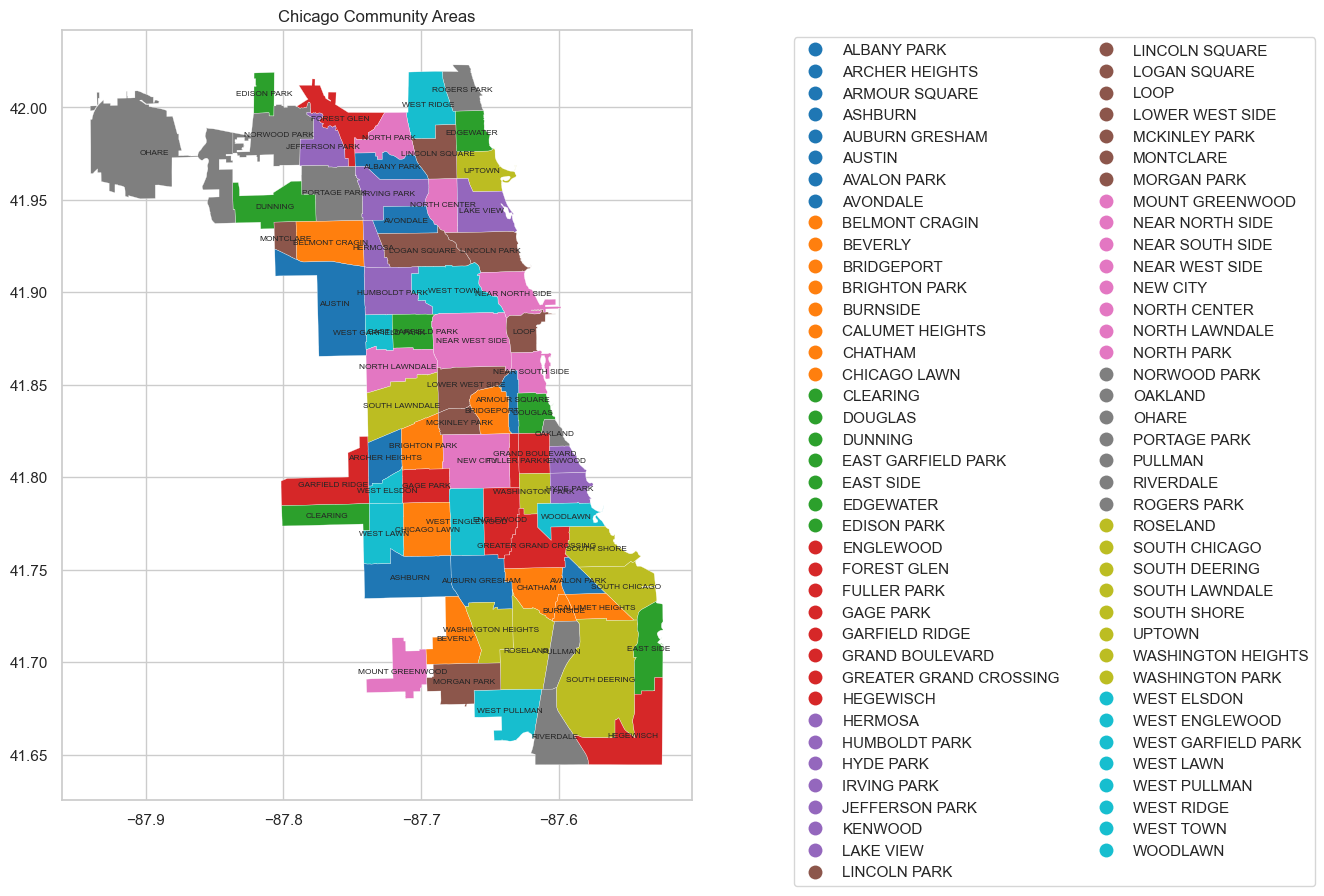

In [23]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 10))

# Plot your GeoDataFrame
chicago = gpd.read_file(r'/Users/gracegormley/Desktop/Stat 303-1/project/Boundaries - Community Areas_20251127/geo_export_a0f75e4e-d093-4b60-9319-7b3e6e34a0ad.shp')
chicago.plot(column='community', ax=ax, legend=True, legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)}, linewidth=0.2)
# Add community labels
for idx, row in chicago.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.text(
        x, y,
        row['community'],
        fontsize=6,
        ha='center',
        va='center'
    )

# Add title (optional)
plt.title('Chicago Community Areas');

# Data Preparation and Cleaning 
*By Grace Gormley*

### Assigning neighborhoods to Divvy, Traffic and Bike Stations

In [24]:
#Okay, for this part, I had chat explain the workflow to me, since I am unfamiliar with shapefile objects. Code is copied over and modified for my datasets

    #Step 1 (since we already have shapefile as geospacial object): convert dataframe
from shapely.geometry import Point
gdf_points = gpd.GeoDataFrame(divvy, geometry = gpd.points_from_xy(divvy.start_lng, divvy.start_lat), crs = "EPSG:4326")

In [25]:
    #Step 2: Making sure they have same coordinate system
print(chicago.crs)
print(gdf_points.crs)

    #Step 3: Now I assign each row to its neighborhood
divvy_nb = gpd.sjoin(gdf_points, chicago, how="left", predicate="within")

EPSG:4326
EPSG:4326


In [26]:
divvy_nb.head()
#YAYYYY

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,geometry,index_right,area_numbe,community,area_num_1,shape_area,shape_len
3486147,6A9D809ABDF70617,electric_bike,2024-01-01 00:00:39,2024-01-01 00:07:56,NaN,NaN,Clark St & Wrightwood Ave,TA1305000014,41.950000,-87.650000,41.929546,-87.643118,member,POINT (-87.65 41.95),5.0,6.0,LAKE VIEW,6,8.721480e+07,51973.096868
3491360,26B9F6E416A68EBA,electric_bike,2024-01-01 00:00:50,2024-01-01 00:04:20,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual,POINT (-87.62 41.9),7.0,8.0,NEAR NORTH SIDE,8,7.667590e+07,57293.164952
3486040,30EF016A0DF5ECEE,electric_bike,2024-01-01 00:00:52,2024-01-01 00:04:25,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual,POINT (-87.62 41.9),7.0,8.0,NEAR NORTH SIDE,8,7.667590e+07,57293.164952
3467452,0D9E85F804C85828,electric_bike,2024-01-01 00:00:53,2024-01-01 00:22:30,Clinton St & Madison St,TA1305000032,NaN,NaN,41.881909,-87.641296,41.890000,-87.620000,member,POINT (-87.6413 41.88191),27.0,28.0,NEAR WEST SIDE,28,1.584925e+08,53003.592941
3410785,56F5C3ED5178C131,classic_bike,2024-01-01 00:01:01,2024-01-01 00:24:12,LaSalle St & Illinois St,13430,Indiana Ave & Roosevelt Rd,SL-005,41.890762,-87.631697,41.867888,-87.623041,member,POINT (-87.6317 41.89076),7.0,8.0,NEAR NORTH SIDE,8,7.667590e+07,57293.164952


In [27]:
#I'll do that with Traffic and bike stations (clean ones)
gdf_points1 = gpd.GeoDataFrame(traffic, geometry = gpd.points_from_xy(traffic['START_LONGITUDE'], traffic[' START_LATITUDE']), crs = "EPSG:4326") #dumb space before lat :\ this took me like 15 minutes to find but oh well :)
traffic = gpd.sjoin(gdf_points1, chicago, how="left", predicate="within")

In [28]:
gdf_points4 = gpd.GeoDataFrame(bike_stations, geometry = gpd.points_from_xy(bike_stations['Longitude'], bike_stations['Latitude']), crs = "EPSG:4326")
bike_stations = gpd.sjoin(gdf_points4, chicago, how="left", predicate="within")

### Cleaning Traffic

In [29]:
traffic.head()
traffic.isnull().sum() #some missing community values... going to try to find where those are

SEGMENTID             0
STREET                0
DIRECTION             0
FROM_STREET           0
TO_STREET             0
LENGTH                0
 STREET_HEADING       0
 COMMENTS          1032
START_LONGITUDE       0
 START_LATITUDE       0
END_LONGITUDE         0
 END_LATITUDE         0
 CURRENT_SPEED        0
 LAST_UPDATED         0
geometry              0
index_right         159
area_numbe          159
community           159
area_num_1          159
shape_area          159
shape_len           159
dtype: int64

Visually looking for where the missing community values are:

Text(0.5, 1.0, 'Chicago Community Areas with Points')

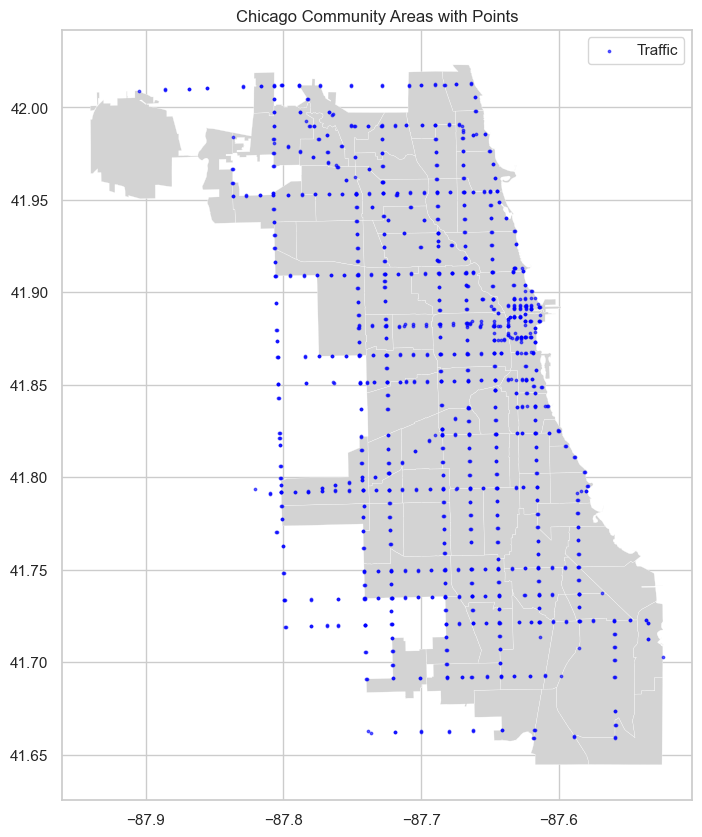

In [30]:
fig, ax = plt.subplots(figsize=(15, 10))

chicago.plot(column='community', ax=ax, color='lightgray',    # light neutral background
    edgecolor='white', legend=False,
             legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)},linewidth=0.2)

gdf_points1.plot(ax=ax, color='blue', markersize=3, alpha=0.6, label='Traffic')

plt.legend()
plt.title('Chicago Community Areas with Points')

In [31]:
# using geopandas 'within' function!
inside = gdf_points1.within(chicago.unary_union)
outside_count = (~inside).sum()

print(f"Points outside Chicago boundaries: {outside_count}")

Points outside Chicago boundaries: 159


Great, it seems the values here that are missing a neighborhood are the ones outside of the neighborhood limit. I'll remove them, since I am going to analyze based on chicago neighborhood.

In [32]:
traffic = traffic.dropna(subset=['community'])
traffic.isnull().sum()
#that cleans it up

SEGMENTID             0
STREET                0
DIRECTION             0
FROM_STREET           0
TO_STREET             0
LENGTH                0
 STREET_HEADING       0
 COMMENTS          1007
START_LONGITUDE       0
 START_LATITUDE       0
END_LONGITUDE         0
 END_LATITUDE         0
 CURRENT_SPEED        0
 LAST_UPDATED         0
geometry              0
index_right           0
area_numbe            0
community             0
area_num_1            0
shape_area            0
shape_len             0
dtype: int64

### Preparing/Cleaning Bus Stops and L Stops

In [33]:
#splitting bus stops and L stops into two coords (right now they have columns like "coordinates" and I need two)
    #bus stops
bus_stops["coords_clean"] = (
    bus_stops["the_geom"]
    .str.replace("POINT (", "", regex=False)
    .str.replace(")", "", regex=False)
)
bus_stops[["LON", "LAT"]] = bus_stops["coords_clean"].str.split(" ", expand=True)
bus_stops["LON"] = bus_stops["LON"].astype(float)
bus_stops["LAT"] = bus_stops["LAT"].astype(float)

gdf_points2 = gpd.GeoDataFrame(bus_stops, geometry = gpd.points_from_xy(bus_stops['LON'], bus_stops['LAT']), crs = "EPSG:4326")
bus_stops = gpd.sjoin(gdf_points2, chicago, how="left", predicate="within")


In [34]:
    #L stops
L_stops["coords_clean"] = (
    L_stops["Location"]
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)
L_stops[["LAT", "LON"]] = L_stops["coords_clean"].str.split(",", expand=True)
L_stops["LON"] = L_stops["LON"].astype(float)
L_stops["LAT"] = L_stops["LAT"].astype(float)

gdf_points3 = gpd.GeoDataFrame(L_stops, geometry = gpd.points_from_xy(L_stops['LON'], L_stops['LAT']), crs = "EPSG:4326")
L_stops = gpd.sjoin(gdf_points3, chicago, how="left", predicate="within")
L_stops.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,...,coords_clean,LAT,LON,geometry,index_right,area_numbe,community,area_num_1,shape_area,shape_len
0,30162,W,18th (54th/Cermak-bound),18th,18th (Pink Line),40830,True,False,False,False,...,"41.857908, -87.669147",41.857908,-87.669147,POINT (-87.66915 41.85791),30.0,31.0,LOWER WEST SIDE,31,8.155072e+07,43229.372704
1,30161,E,18th (Loop-bound),18th,18th (Pink Line),40830,True,False,False,False,...,"41.857908, -87.669147",41.857908,-87.669147,POINT (-87.66915 41.85791),30.0,31.0,LOWER WEST SIDE,31,8.155072e+07,43229.372704
2,30022,N,35th/Archer (Loop-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,...,"41.829353, -87.680622",41.829353,-87.680622,POINT (-87.68062 41.82935),58.0,59.0,MCKINLEY PARK,59,3.943180e+07,26014.096837
3,30023,S,35th/Archer (Midway-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,...,"41.829353, -87.680622",41.829353,-87.680622,POINT (-87.68062 41.82935),58.0,59.0,MCKINLEY PARK,59,3.943180e+07,26014.096837
4,30213,N,35-Bronzeville-IIT (Harlem-bound),35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),41120,True,False,False,True,...,"41.831677, -87.625826",41.831677,-87.625826,POINT (-87.62583 41.83168),34.0,35.0,DOUGLAS,35,4.600462e+07,31027.054510


## EDA: Visualizing the physical distribution of variables by neighborhood

(I went back to this graph a lot during my analysis, commenting out the irrelevant data so it's not too crowded. I know it's tough to read now, it was more for reference for me.)

Text(0.5, 1.0, 'Chicago Community Areas with Points')

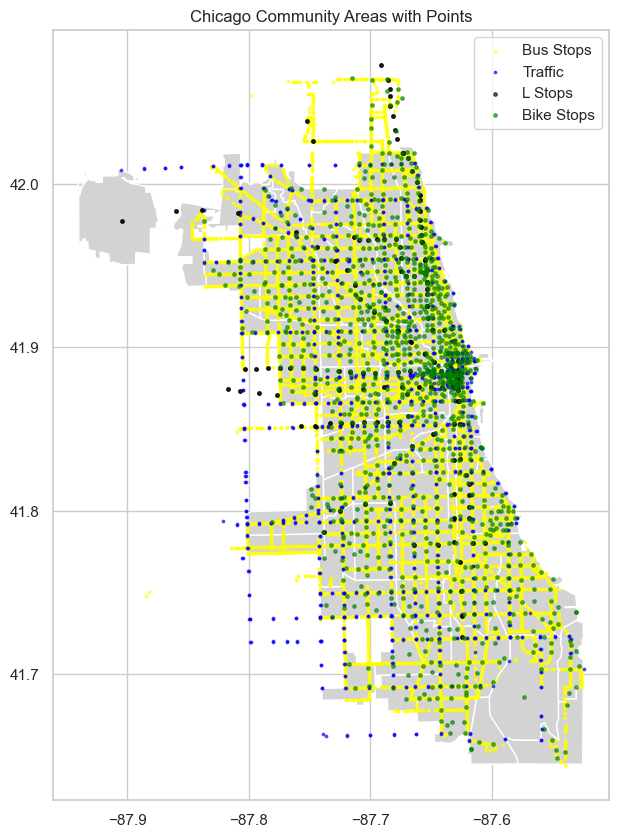

In [35]:
fig, ax = plt.subplots(figsize=(15, 10))

chicago.plot(column='community', ax=ax, color='lightgray',    # light neutral background
    edgecolor='white', legend=False,
             legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})

gdf_points2.plot(ax=ax, color='yellow', markersize=3, alpha=0.6, label='Bus Stops')
gdf_points1.plot(ax=ax, color='blue', markersize=3, alpha=0.6, label='Traffic')
gdf_points3.plot(ax=ax, color='black', markersize=6, alpha=0.6, label='L Stops')
gdf_points4.plot(ax=ax, color='green', markersize=6, alpha=0.6, label='Bike Stops')


#gdf_points.plot(ax=ax, color='blue', markersize=10, alpha=0.6, label='divvy_ride_start') this shows the divvy points and takes about 1 million years to load

plt.legend()
plt.title('Chicago Community Areas with Points')


## Cleaning/Prepping Traffic and Population

In [36]:
#for traffic: A value of -1 means no estimate is available, according to the documentation, so I'll clean them up and get rid of them
traffic_cleaned = traffic[traffic[' CURRENT_SPEED'] != -1]

traffic_cleaned_neighb = traffic_cleaned.groupby(['community'])[' CURRENT_SPEED'].agg(['mean'])
traffic_cleaned_neighb.reset_index(inplace=True)
traffic_cleaned_neighb = traffic_cleaned_neighb.rename(columns={'mean':'avg_traffic_speed'})

traffic_cleaned_neighb #this I will append to whatever finished product I have

,community,avg_traffic_speed
0,ALBANY PARK,22.333333
1,ARCHER HEIGHTS,23.555556
2,ARMOUR SQUARE,23.750000
3,ASHBURN,25.304348
4,AUBURN GRESHAM,23.107143
...,...,...
69,WEST LAWN,24.888889
70,WEST PULLMAN,32.333333
71,WEST RIDGE,22.285714
72,WEST TOWN,21.421053


<Axes: ylabel='Frequency'>

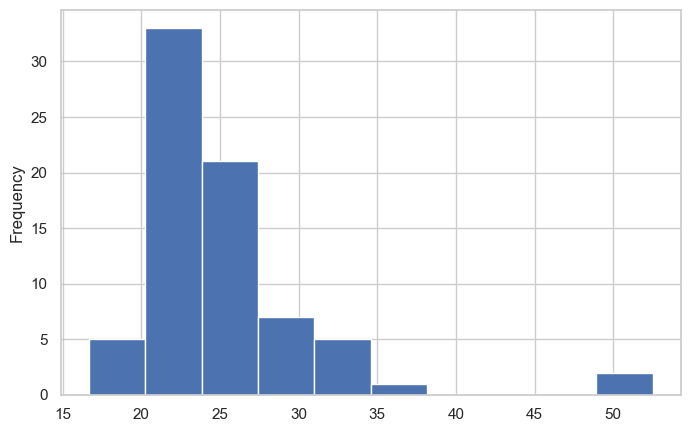

In [37]:
traffic_cleaned_neighb.avg_traffic_speed.plot.hist() #making sure the traffic isn't all too similar for analysis. It looks like it has some interesting distribution. 

In [38]:
#cleaning population (removing 2023) - I'm removing 2023 since my divvy data is 2024-2025 only
population['ACS Year'] = pd.to_datetime(population['ACS Year'], errors='coerce')
population = population[population['ACS Year'].dt.year != 2023]

#finding avg pop per neighborhood (since divvy data is 2024-2025, I'll average populations)
population_avg = population.groupby(['Community Area'])['Total Population'].agg(['mean'])
population_avg.reset_index(inplace=True)
population_avg = population_avg.rename(columns={'Community Area': 'community', 'mean':'population_avg'})
population_avg #yay! this is good for my per capita table!


,community,population_avg
0,ALBANY PARK,47830.0
1,ARCHER HEIGHTS,13875.0
2,ARMOUR SQUARE,13149.0
3,ASHBURN,42842.0
4,AUBURN GRESHAM,46483.0
...,...,...
72,WEST LAWN,32451.0
73,WEST PULLMAN,25159.0
74,WEST RIDGE,79220.0
75,WEST TOWN,86453.0


## Final Prep of Each Dataframe before Joining

Okay, at this point, I could make a table with population, mean traffic. I need to organize # of L stops, # of divvy stops, # of bus stops by neighborhood. Finally then I will add the divvy data and per capita data, and deal with the messes there. 

In [39]:
num_L_stops = (L_stops.groupby('community')['MAP_ID'].nunique().reset_index().rename(columns={'MAP_ID': 'num_L_stops'}))

num_bus_stops = (bus_stops.groupby('community')['SYSTEMSTOP'].nunique().reset_index().rename(columns={'SYSTEMSTOP': 'num_bus_stops'}))

num_bike_stops = (bike_stations.groupby('community')['ID'].nunique().reset_index().rename(columns={'ID': 'num_bike_stops'}))

num_L_stops.head()

,community,num_L_stops
0,ALBANY PARK,3
1,ARMOUR SQUARE,2
2,AUSTIN,5
3,AVONDALE,1
4,BRIDGEPORT,1


In [40]:
num_bike_stops.head()

,community,num_bike_stops
0,ALBANY PARK,8
1,ARCHER HEIGHTS,9
2,ARMOUR SQUARE,9
3,ASHBURN,13
4,AUBURN GRESHAM,11


In [41]:
num_L_stops.head()

,community,num_L_stops
0,ALBANY PARK,3
1,ARMOUR SQUARE,2
2,AUSTIN,5
3,AVONDALE,1
4,BRIDGEPORT,1


In [42]:
divvy_nb_count = (divvy_nb.groupby('community')['ride_id'].nunique().reset_index().rename(columns={'ride_id': 'num_divvy_rides'}))
divvy_nb_count.head()

,community,num_divvy_rides
0,ALBANY PARK,25540
1,ARCHER HEIGHTS,3470
2,ARMOUR SQUARE,65029
3,ASHBURN,2263
4,AUBURN GRESHAM,3112


Okay! I think everything is ready to concatenate my first comparison dataset!

## Making the dataset

In [43]:
merged = population_avg \
    .merge(num_L_stops, on='community', how='left') \
    .merge(num_bus_stops, on='community', how='left') \
    .merge(num_bike_stops, on='community', how='left') \
    .merge(divvy_nb_count, on='community', how = 'left') \
    .merge(traffic_cleaned_neighb, on='community', how='left') 

merged

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333
1,ARCHER HEIGHTS,13875.0,NaN,66,9.0,3470,23.555556
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000
3,ASHBURN,42842.0,NaN,131,13.0,2263,25.304348
4,AUBURN GRESHAM,46483.0,NaN,172,11.0,3112,23.107143
...,...,...,...,...,...,...,...
72,WEST LAWN,32451.0,NaN,79,10.0,2556,24.888889
73,WEST PULLMAN,25159.0,NaN,104,11.0,1153,32.333333
74,WEST RIDGE,79220.0,NaN,195,21.0,35596,22.285714
75,WEST TOWN,86453.0,4.0,287,56.0,778781,21.421053


In [44]:
#this is the per capita ones

merged['L_stops_per_capita'] = merged['num_L_stops'] / merged['population_avg']
merged['bus_stops_per_capita'] = merged['num_bus_stops'] / merged['population_avg']
merged['bike_stops_per_capita'] = merged['num_bike_stops'] / merged['population_avg']
merged['divvy_per_capita'] = merged['num_divvy_rides'] / merged['population_avg']

merged


,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974
1,ARCHER HEIGHTS,13875.0,NaN,66,9.0,3470,23.555556,NaN,0.004757,0.000649,0.250090
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547
3,ASHBURN,42842.0,NaN,131,13.0,2263,25.304348,NaN,0.003058,0.000303,0.052822
4,AUBURN GRESHAM,46483.0,NaN,172,11.0,3112,23.107143,NaN,0.003700,0.000237,0.066949
...,...,...,...,...,...,...,...,...,...,...,...
72,WEST LAWN,32451.0,NaN,79,10.0,2556,24.888889,NaN,0.002434,0.000308,0.078765
73,WEST PULLMAN,25159.0,NaN,104,11.0,1153,32.333333,NaN,0.004134,0.000437,0.045829
74,WEST RIDGE,79220.0,NaN,195,21.0,35596,22.285714,NaN,0.002461,0.000265,0.449331
75,WEST TOWN,86453.0,4.0,287,56.0,778781,21.421053,0.000046,0.003320,0.000648,9.008143


## Adding a population density metric

In [45]:
chicago_proj = chicago.to_crs(epsg=3435)  # Illinois State Plane in meters (got this conversion line from AI after the first time didn't work)

chicago_proj['area_sqm'] = chicago_proj.geometry.area

chicago_proj['area_km2'] = chicago_proj['area_sqm'] / 1e6 #convert to km

neighborhood_areas = chicago_proj[['community', 'area_km2']]
print(neighborhood_areas)

             community    area_km2
0          ROGERS PARK   51.259902
1           WEST RIDGE   98.429095
2               UPTOWN   65.095643
3       LINCOLN SQUARE   71.352328
4         NORTH CENTER   57.054168
..                 ...         ...
72  WASHINGTON HEIGHTS   79.635753
73     MOUNT GREENWOOD   75.584290
74         MORGAN PARK   91.877341
75               OHARE  371.835608
76           EDGEWATER   48.449991

[77 rows x 2 columns]


In [46]:
merged = merged \
    .merge(neighborhood_areas, on='community', how='left')

merged['pop_density'] = merged['population_avg']/merged['area_km2']
merged

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974,53.542231,893.313545
1,ARCHER HEIGHTS,13875.0,NaN,66,9.0,3470,23.555556,NaN,0.004757,0.000649,0.250090,55.922506,248.111200
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547,27.766196,473.561447
3,ASHBURN,42842.0,NaN,131,13.0,2263,25.304348,NaN,0.003058,0.000303,0.052822,135.460337,316.269699
4,AUBURN GRESHAM,46483.0,NaN,172,11.0,3112,23.107143,NaN,0.003700,0.000237,0.066949,105.065354,442.419869
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,WEST LAWN,32451.0,NaN,79,10.0,2556,24.888889,NaN,0.002434,0.000308,0.078765,82.315302,394.228040
73,WEST PULLMAN,25159.0,NaN,104,11.0,1153,32.333333,NaN,0.004134,0.000437,0.045829,99.365198,253.197301
74,WEST RIDGE,79220.0,NaN,195,21.0,35596,22.285714,NaN,0.002461,0.000265,0.449331,98.429095,804.843325
75,WEST TOWN,86453.0,4.0,287,56.0,778781,21.421053,0.000046,0.003320,0.000648,9.008143,127.562905,677.728375


## Cleaning the Merged Dataset

In [47]:
merged.isnull().sum()

community                 0
population_avg            0
num_L_stops              35
num_bus_stops             0
num_bike_stops            3
num_divvy_rides           0
avg_traffic_speed         3
L_stops_per_capita       35
bus_stops_per_capita      0
bike_stops_per_capita     3
divvy_per_capita          0
area_km2                  0
pop_density               0
dtype: int64

surprisingly very few null values here.... i know the row would be n/an if there's a zero for the rows where I applied the value_counts funtion (since that's how value_counts deal with 0s), which is L_stops and bike_stops. Let's double check that. 

Text(0.5, 1.0, 'Chicago Community Areas with Points')

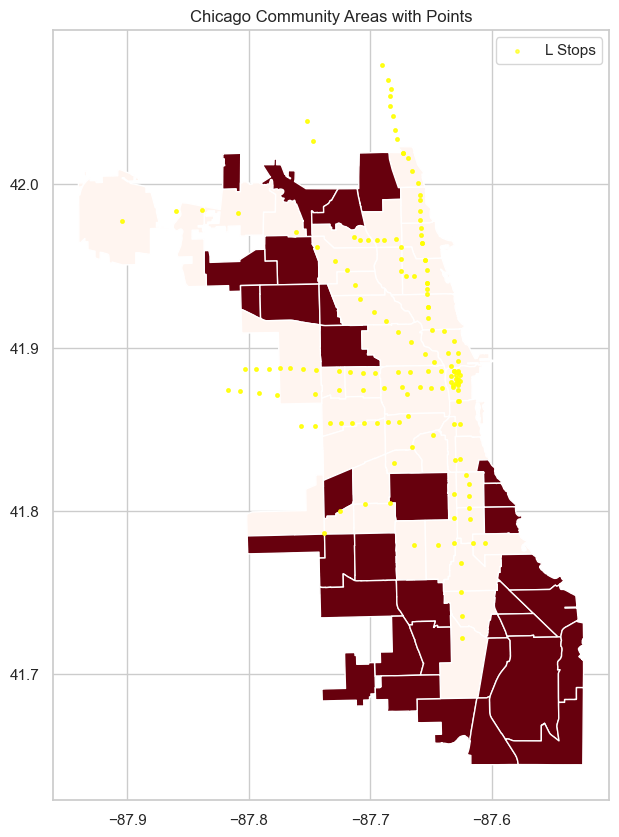

In [48]:
#printing the neighborhoods with null L stops
no_L = merged.loc[merged['num_L_stops'].isna(), 'community'].unique()


#trying to see graphically - this should highlight red the null communities and also print the L stops, so I can see if there is overlap (if i'm right there should be none)
fig, ax = plt.subplots(figsize=(15, 10))

chicago['highlight'] = chicago['community'].isin(no_L)

chicago.plot(column='highlight', ax=ax, cmap='Reds', edgecolor='white', legend=False)

gdf_points3.plot(ax=ax, color='yellow', markersize=6, alpha=0.6, label='L Stops') #trying yellow since it'll show up well on the dark red maybe

plt.legend()
plt.title('Chicago Community Areas with Points')


Yay! There is no yellow in ay of the red boxes, so it looks like for L stops, a null value means zero. Let's check bike stops. 

Text(0.5, 1.0, 'Chicago Community Areas with Points')

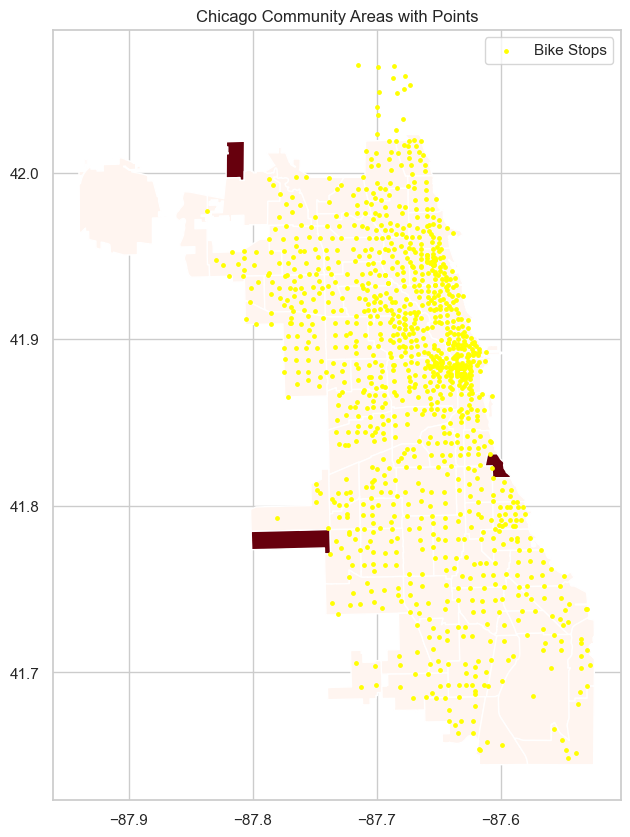

In [49]:
#printing the neighborhoods with null L stops
no_bike = merged.loc[merged['num_bike_stops'].isna(), 'community'].unique()


#trying to see graphically (same code)
fig, ax = plt.subplots(figsize=(15, 10))

chicago['highlight2'] = chicago['community'].isin(no_bike)

chicago.plot(column='highlight2', ax=ax, cmap='Reds', edgecolor='white', legend=False)

gdf_points4.plot(ax=ax, color='yellow', markersize=6, alpha=1, label='Bike Stops') 

plt.legend()
plt.title('Chicago Community Areas with Points')


Looks like the same for bike stops. N/A means zero. Let's impute those.

In [50]:
cols_to_impute = ['num_L_stops', 'num_bike_stops', 'L_stops_per_capita', 'bike_stops_per_capita']
merged[cols_to_impute] = merged[cols_to_impute].fillna(0)
merged.isna().sum()

community                0
population_avg           0
num_L_stops              0
num_bus_stops            0
num_bike_stops           0
num_divvy_rides          0
avg_traffic_speed        3
L_stops_per_capita       0
bus_stops_per_capita     0
bike_stops_per_capita    0
divvy_per_capita         0
area_km2                 0
pop_density              0
dtype: int64

Now let's look into the null traffic speed. 

In [51]:
merged[merged.isna().any(axis=1)]


,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density
19,EAST GARFIELD PARK,19855.0,4.0,136,14.0,9877,NaN,0.000201,0.006850,0.000705,0.497457,53.883221,368.482056
30,HEGEWISCH,8895.0,0.0,47,6.0,1093,NaN,0.000000,0.005284,0.000675,0.122878,145.965741,60.938957
62,SOUTH CHICAGO,29072.0,0.0,117,10.0,3859,NaN,0.000000,0.004024,0.000344,0.132739,93.272185,311.689921


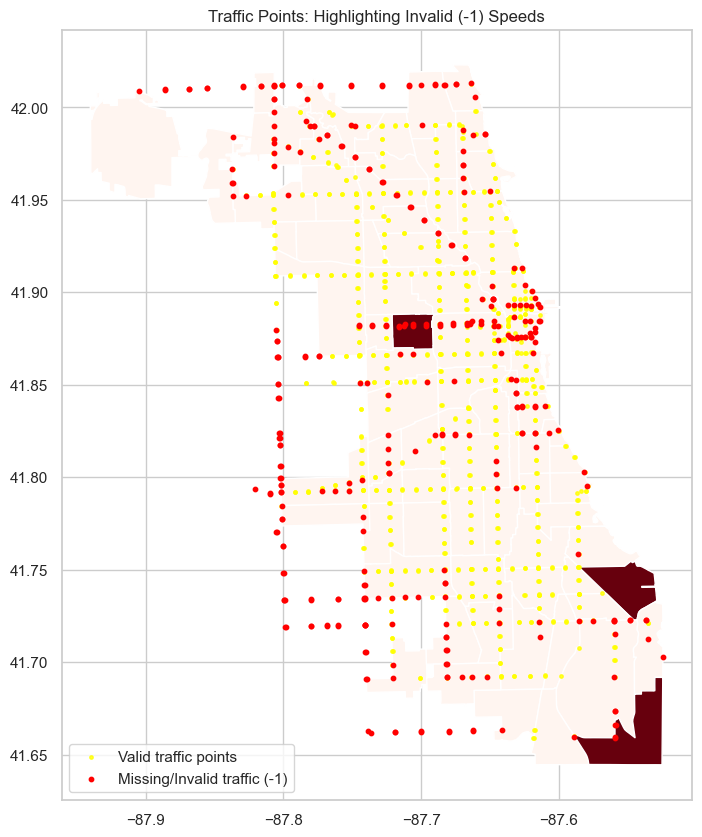

In [52]:
gdf_points_bad = gdf_points1[gdf_points1[' CURRENT_SPEED'] == -1]
gdf_points_good = gdf_points1[gdf_points1[' CURRENT_SPEED'] != -1]

null_traff = merged.loc[merged['avg_traffic_speed'].isna(), 'community'].unique() #mask for the neighborhoods

#same code as above
fig, ax = plt.subplots(figsize=(15, 10))

chicago['highlight3'] = chicago['community'].isin(null_traff)


chicago.plot(column='highlight3', ax=ax, cmap='Reds', edgecolor='white', legend=False)

gdf_points_good.plot(ax=ax, color='yellow', markersize=6, alpha=0.8, label='Valid traffic points') #if there is a yellow in my red blocks, something's wrong. it should be all red if my hunch is right and all the data there is -1

gdf_points_bad.plot(ax=ax, color='red', markersize=10, alpha=1, label='Missing/Invalid traffic (-1)')

plt.legend()
plt.title('Traffic Points: Highlighting Invalid (-1) Speeds');


Okay, since there is no yellow in the red polygons, that means the estimated traffic speed in those areas was -1, meaning no estimate was available, and I dropped the value. I don't want to remove the community, so I'll just remember those are null for that reason.

## Data Prep
- I've already done some prep, like some standardziation (per capita measurements)
- I think, since I have so many categories (communities) it would benefit me to bin them (for histogram data, etc)

https://en.wikipedia.org/wiki/Community_areas_in_Chicago

https://research.dom.edu/governmentdata/chicago 

- These links say that there are established 9 regions (sort of just divided into sides). I'll bin them in this way. I think maybe the cleanest way to do it is to sum the non-per-capita data, and recalculate per capita stuff. 

### Assigning each neighborhood to a "side"

In [53]:
#making a dictionary to divide into "sides" (I uploaded an image to gemini and had it make the dictionary since it would just be tedious.)

chicago_sides = {
    # FAR NORTH SIDE
    'ROGERS PARK': 'FAR NORTH SIDE',
    'WEST RIDGE': 'FAR NORTH SIDE',
    'UPTOWN': 'FAR NORTH SIDE',
    'LINCOLN SQUARE': 'FAR NORTH SIDE',
    'EDISON PARK': 'FAR NORTH SIDE',
    'NORWOOD PARK': 'FAR NORTH SIDE',
    'JEFFERSON PARK': 'FAR NORTH SIDE',
    'FOREST GLEN': 'FAR NORTH SIDE',
    'NORTH PARK': 'FAR NORTH SIDE',
    'ALBANY PARK': 'FAR NORTH SIDE',
    'EDGEWATER': 'FAR NORTH SIDE',
    "OHARE": 'FAR NORTH SIDE',  # CA 76

    # NORTH SIDE
    'NORTH CENTER': 'NORTH SIDE',
    'LAKE VIEW': 'NORTH SIDE',
    'LINCOLN PARK': 'NORTH SIDE',
    'AVONDALE': 'NORTH SIDE',
    'LOGAN SQUARE': 'NORTH SIDE',

    # NORTH WEST SIDE (Note: Image title is "North West Side", not "Northwest Side")
    'PORTAGE PARK': 'NORTH WEST SIDE',
    'IRVING PARK': 'NORTH WEST SIDE',
    'DUNNING': 'NORTH WEST SIDE',
    'MONTCLARE': 'NORTH WEST SIDE',
    'BELMONT CRAGIN': 'NORTH WEST SIDE',
    'HERMOSA': 'NORTH WEST SIDE',

    # WEST SIDE
    'HUMBOLDT PARK': 'WEST SIDE',
    'WEST TOWN': 'WEST SIDE',
    'AUSTIN': 'WEST SIDE',
    'WEST GARFIELD PARK': 'WEST SIDE',
    'EAST GARFIELD PARK': 'WEST SIDE',
    'NEAR WEST SIDE': 'WEST SIDE',
    'NORTH LAWNDALE': 'WEST SIDE',
    'SOUTH LAWNDALE': 'WEST SIDE',
    'LOWER WEST SIDE': 'WEST SIDE',

    # CENTRAL
    'NEAR NORTH SIDE': 'CENTRAL',
    'LOOP': 'CENTRAL',
    'NEAR SOUTH SIDE': 'CENTRAL',

    # SOUTH SIDE
    'ARMOUR SQUARE': 'SOUTH SIDE',
    'DOUGLAS': 'SOUTH SIDE',
    'OAKLAND': 'SOUTH SIDE',
    'FULLER PARK': 'SOUTH SIDE',
    'GRAND BOULEVARD': 'SOUTH SIDE',
    'KENWOOD': 'SOUTH SIDE',
    'WASHINGTON PARK': 'SOUTH SIDE',
    'HYDE PARK': 'SOUTH SIDE',
    'WOODLAWN': 'SOUTH SIDE',
    'SOUTH SHORE': 'SOUTH SIDE',
    'BRIDGEPORT': 'SOUTH SIDE', # Grouped here in the image's structure
    'GREATER GRAND CROSSING': 'SOUTH SIDE',

    # SOUTHWEST SIDE
    'GARFIELD RIDGE': 'SOUTHWEST SIDE',
    'ARCHER HEIGHTS': 'SOUTHWEST SIDE',
    'BRIGHTON PARK': 'SOUTHWEST SIDE',
    'MCKINLEY PARK': 'SOUTHWEST SIDE',
    'NEW CITY': 'SOUTHWEST SIDE',
    'WEST ELSDON': 'SOUTHWEST SIDE',
    'GAGE PARK': 'SOUTHWEST SIDE',
    'CLEARING': 'SOUTHWEST SIDE',
    'WEST LAWN': 'SOUTHWEST SIDE',
    'CHICAGO LAWN': 'SOUTHWEST SIDE',
    'WEST ENGLEWOOD': 'SOUTHWEST SIDE',
    'ENGLEWOOD': 'SOUTHWEST SIDE',

    # FAR SOUTHWEST SIDE
    'ASHBURN': 'FAR SOUTHWEST SIDE',
    'AUBURN GRESHAM': 'FAR SOUTHWEST SIDE',
    'BEVERLY': 'FAR SOUTHWEST SIDE',
    'WASHINGTON HEIGHTS': 'FAR SOUTHWEST SIDE',
    'MOUNT GREENWOOD': 'FAR SOUTHWEST SIDE',
    'MORGAN PARK': 'FAR SOUTHWEST SIDE',

    # FAR SOUTHEAST SIDE
    'CHATHAM': 'FAR SOUTHEAST SIDE',
    'AVALON PARK': 'FAR SOUTHEAST SIDE',
    'SOUTH CHICAGO': 'FAR SOUTHEAST SIDE',
    'BURNSIDE': 'FAR SOUTHEAST SIDE',
    'CALUMET HEIGHTS': 'FAR SOUTHEAST SIDE',
    'ROSELAND': 'FAR SOUTHEAST SIDE',
    'PULLMAN': 'FAR SOUTHEAST SIDE',
    'SOUTH DEERING': 'FAR SOUTHEAST SIDE',
    'EAST SIDE': 'FAR SOUTHEAST SIDE',
    'WEST PULLMAN': 'FAR SOUTHEAST SIDE',
    'RIVERDALE': 'FAR SOUTHEAST SIDE',
    'HEGEWISCH': 'FAR SOUTHEAST SIDE',
}

In [54]:
merged['side'] = merged['community'].map(chicago_sides)

merged.head()

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density,side
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974,53.542231,893.313545,FAR NORTH SIDE
1,ARCHER HEIGHTS,13875.0,0.0,66,9.0,3470,23.555556,0.000000,0.004757,0.000649,0.250090,55.922506,248.111200,SOUTHWEST SIDE
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547,27.766196,473.561447,SOUTH SIDE
3,ASHBURN,42842.0,0.0,131,13.0,2263,25.304348,0.000000,0.003058,0.000303,0.052822,135.460337,316.269699,FAR SOUTHWEST SIDE
4,AUBURN GRESHAM,46483.0,0.0,172,11.0,3112,23.107143,0.000000,0.003700,0.000237,0.066949,105.065354,442.419869,FAR SOUTHWEST SIDE


I want to visualize them to make sure I'm not missing any neighborhoods

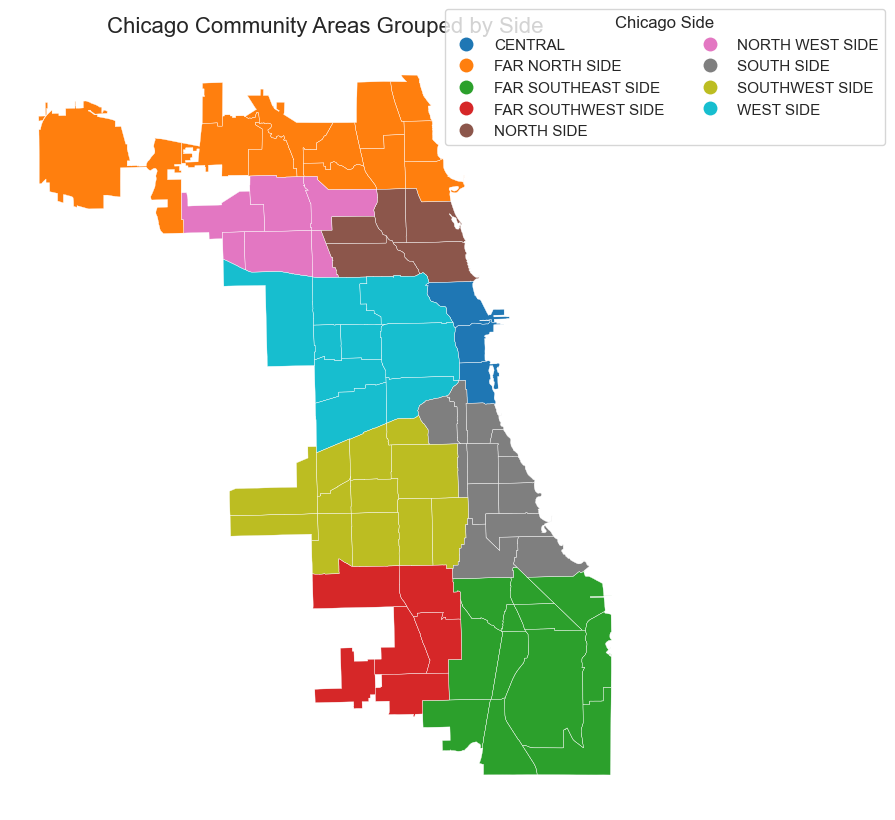

In [55]:
chicago['side'] = chicago['community'].map(chicago_sides) #mapping sides to the communties so I can graph to see the sections

fig, ax = plt.subplots(figsize=(15, 10))

chicago.plot(
    column='side', 
    ax=ax, 
    legend=True, 
    cmap='tab10',  # Using a good categorical colormap
    legend_kwds={'ncol': 2, 'bbox_to_anchor': (1.4, 1.05), 'title': 'Chicago Side'}, linewidth=0.2
)

#gdf_points4.plot(ax=ax, color='white', markersize=6, alpha=0.6, label='Bike Stops')

chicago.boundary.plot(ax=ax, linewidth=0.1, color='white')
ax.set_axis_off()

plt.title('Chicago Community Areas Grouped by Side', fontsize=16)
plt.show()

In [56]:
#Initially we were missing ohare and the loop so I added those. (Loop was called "the Loop" in dictonary and ohare was called "O'hare"). It looks good after fixing that. 

### Making a binned dataset

Now that I have added the "sides" bins, I need to make a new dataframe with the combined information. 

In [57]:
side_data = merged.groupby('side').agg(
    #sums for not per-capita-data (CAREFUL TO GET SAME ORDER FOR CORRELATION MATRIX GRAPH LATER)

    Total_Population=('population_avg', 'sum'),
    Total_L_Stops=('num_L_stops', 'sum'),
    Total_Bus_Stops=('num_bus_stops', 'sum'),
    Total_Divvy_Stations=('num_bike_stops', 'sum'),
    Total_Divvy_Rides=('num_divvy_rides', 'sum')
)
side_data.head()


,Total_Population,Total_L_Stops,Total_Bus_Stops,Total_Divvy_Stations,Total_Divvy_Rides
side,,,,,
CENTRAL,156226.0,25.0,493,134.0,3734447
FAR NORTH SIDE,456323.0,22.0,1241,119.0,878282
FAR SOUTHEAST SIDE,209345.0,3.0,1046,92.0,20394
FAR SOUTHWEST SIDE,175841.0,0.0,656,50.0,12637
NORTH SIDE,296205.0,15.0,844,178.0,2968640


In [58]:
# I need the original traffic dataset (with community) to get good averages. If I average
# based on merged, then each neighborhood has equal weight, and I think it will be more accurate if I go from the start,
# where each route is weighted equally

traffic['side'] = traffic['community'].map(chicago_sides) #adding "side"
traffic_cleaned2 = traffic[traffic[' CURRENT_SPEED'] != -1] #getting rid of -1s (no data)

#same process as I did above to get the avg by community.
traffic_cleaned_side = traffic_cleaned2.groupby(['side'])[' CURRENT_SPEED'].agg(['mean'])
traffic_cleaned_side.reset_index(inplace=True)
traffic_cleaned_side = traffic_cleaned_side.rename(columns={'mean':'avg_traffic_speed_side'})

traffic_cleaned_side.head()
#okay this looks good. I'll join with the one above^

,side,avg_traffic_speed_side
0,CENTRAL,22.500000
1,FAR NORTH SIDE,24.725000
2,FAR SOUTHEAST SIDE,26.623188
3,FAR SOUTHWEST SIDE,24.487500
4,NORTH SIDE,23.917808


In [59]:
side_data = side_data \
    .merge(traffic_cleaned_side, on=['side'], how='left')

side_data

,side,Total_Population,Total_L_Stops,Total_Bus_Stops,Total_Divvy_Stations,Total_Divvy_Rides,avg_traffic_speed_side
0,CENTRAL,156226.0,25.0,493,134.0,3734447,22.500000
1,FAR NORTH SIDE,456323.0,22.0,1241,119.0,878282,24.725000
2,FAR SOUTHEAST SIDE,209345.0,3.0,1046,92.0,20394,26.623188
3,FAR SOUTHWEST SIDE,175841.0,0.0,656,50.0,12637,24.487500
4,NORTH SIDE,296205.0,15.0,844,178.0,2968640,23.917808
5,NORTH WEST SIDE,271227.0,3.0,898,89.0,119101,22.896552
6,SOUTH SIDE,246744.0,14.0,1295,114.0,709917,27.386667
7,SOUTHWEST SIDE,358308.0,8.0,1472,111.0,48670,24.884058
8,WEST SIDE,477402.0,34.0,1983,250.0,2244765,22.100000


In [60]:
#Now I need the per capita. I'll reuse my code.
side_data['L_stops_per_capita'] = side_data['Total_L_Stops'] / side_data['Total_Population']
side_data['bus_stops_per_capita'] = side_data['Total_Bus_Stops'] / side_data['Total_Population']
side_data['bike_stops_per_capita'] = side_data['Total_Divvy_Stations'] / side_data['Total_Population']
side_data['divvy_per_capita'] = side_data['Total_Divvy_Rides'] / side_data['Total_Population']

side_data

,side,Total_Population,Total_L_Stops,Total_Bus_Stops,Total_Divvy_Stations,Total_Divvy_Rides,avg_traffic_speed_side,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita
0,CENTRAL,156226.0,25.0,493,134.0,3734447,22.500000,0.000160,0.003156,0.000858,23.904132
1,FAR NORTH SIDE,456323.0,22.0,1241,119.0,878282,24.725000,0.000048,0.002720,0.000261,1.924694
2,FAR SOUTHEAST SIDE,209345.0,3.0,1046,92.0,20394,26.623188,0.000014,0.004997,0.000439,0.097418
3,FAR SOUTHWEST SIDE,175841.0,0.0,656,50.0,12637,24.487500,0.000000,0.003731,0.000284,0.071866
4,NORTH SIDE,296205.0,15.0,844,178.0,2968640,23.917808,0.000051,0.002849,0.000601,10.022248
5,NORTH WEST SIDE,271227.0,3.0,898,89.0,119101,22.896552,0.000011,0.003311,0.000328,0.439119
6,SOUTH SIDE,246744.0,14.0,1295,114.0,709917,27.386667,0.000057,0.005248,0.000462,2.877140
7,SOUTHWEST SIDE,358308.0,8.0,1472,111.0,48670,24.884058,0.000022,0.004108,0.000310,0.135833
8,WEST SIDE,477402.0,34.0,1983,250.0,2244765,22.100000,0.000071,0.004154,0.000524,4.702044


In [61]:
side_data.isnull().sum()

side                      0
Total_Population          0
Total_L_Stops             0
Total_Bus_Stops           0
Total_Divvy_Stations      0
Total_Divvy_Rides         0
avg_traffic_speed_side    0
L_stops_per_capita        0
bus_stops_per_capita      0
bike_stops_per_capita     0
divvy_per_capita          0
dtype: int64

Great, this is my binned dataset.

# Exploration and Analysis

## 1: Correlation Matrix Overall (unbinned, both per cap and not per cap)
I'm using unbinned since having 77 rows gives more robust correlation estimates than only 9.

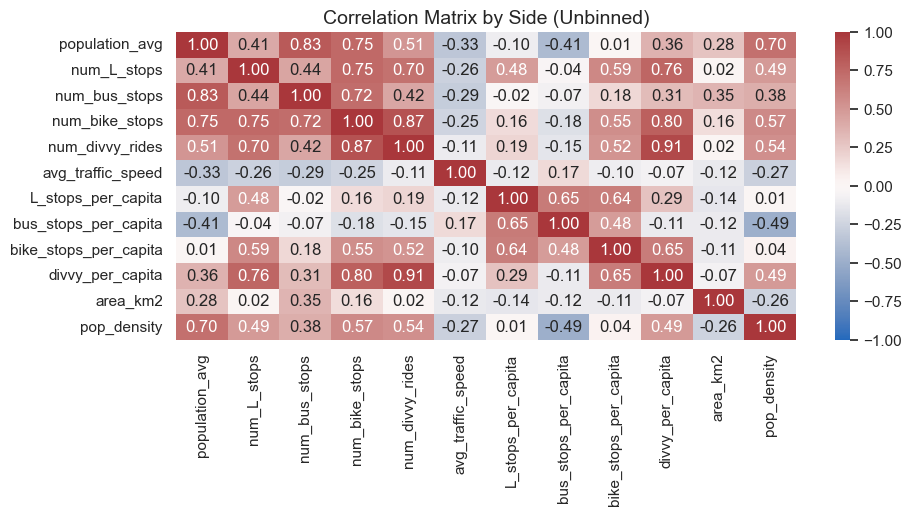

In [62]:
fig, (ax1) = plt.subplots(1, figsize=(10, 4))

sns.heatmap(merged.select_dtypes(include='number').corr(), cmap='vlag', annot=True, fmt=".2f", ax=ax1, vmin = -1, vmax=1) #picked vlag since that emphazises strong negative and positive corr
ax1.set_title('Correlation Matrix by Side (Unbinned)', fontsize=14);

### Interesting / Unexpected Things
1) Traffic speed is almost unrelated to the transit infrastructure per capita and to divvy bike rides. This seems probably inaccurate (meaning unfortunately I may just not have enough traffic intel).
2) Population density is related to divvy rides (0.49) but not to bike stops (0.04)
3) Transit availability are all strongly related (L stops per cap, Bus stops per cap, bike stops per cap all have ~0.5 or higher), but bike RIDES per cap is only related with bike stops. 

Let's dive deeper into questions 2 and 3.

### Question 2: Population Density vs Divvy Rides

I'll make a ratio of # of rides vs # of stations and graph that over population density. 

<Axes: xlabel='pop_density', ylabel='rides_per_station'>

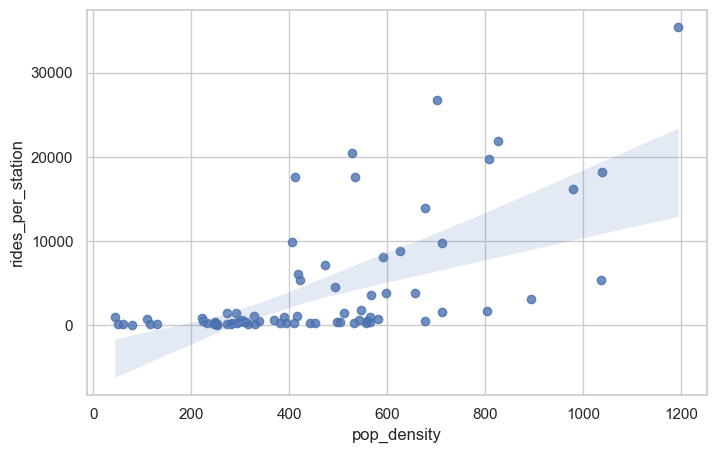

In [63]:
merged['rides_per_station'] = (merged['num_divvy_rides'] / merged['num_bike_stops'])

sns.regplot(data=merged,x='pop_density',y='rides_per_station')

# Infrastructure mismatch -  the higher pop density leads to overused stations

Since rides per station tends to increase based on population data, this suggests that the stops are placed to cover geographic area, not be more dense in areas with denser need. Let's explore this further with three density graphs:  

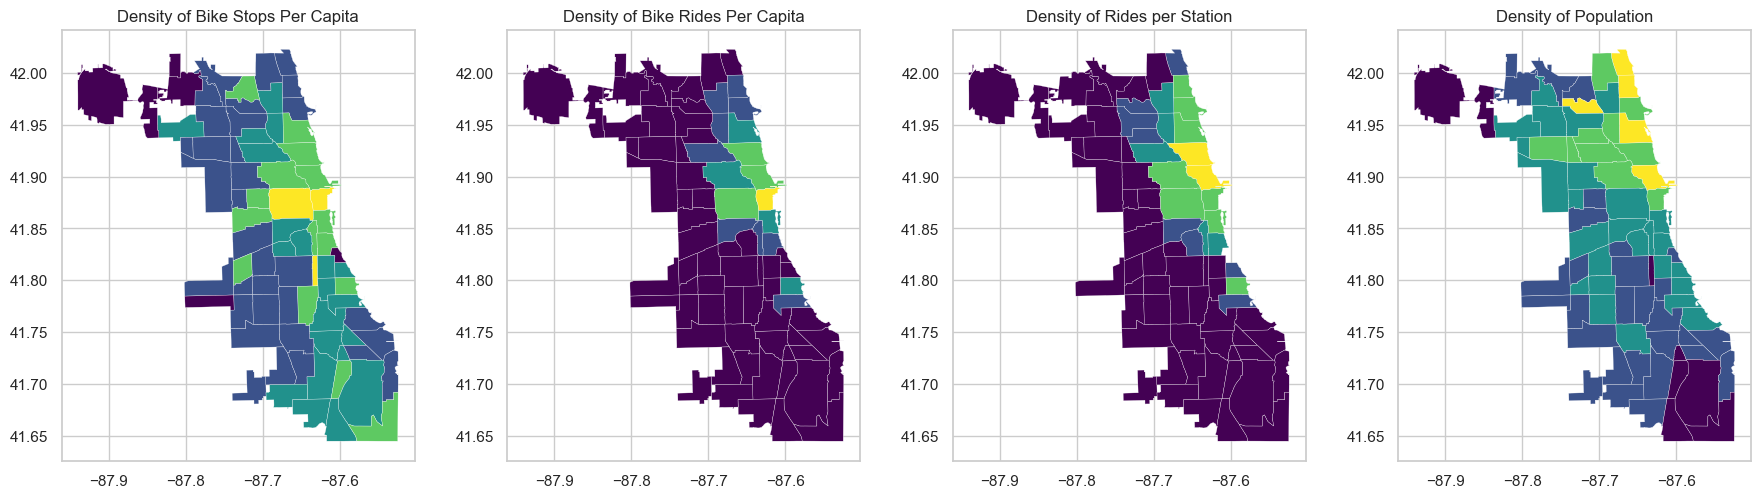

In [72]:
chicago_merge = chicago.merge(merged, on=['community'], how='left')

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=False, sharey=False)

#Bike stops
chicago_merge.plot(
    column='bike_stops_per_capita', 
    legend=False,
    cmap='viridis',
    scheme='NaturalBreaks',
    ax=axes[0], linewidth=0.2)
axes[0].set_title("Density of Bike Stops Per Capita")

#Bike Rides
chicago_merge.plot(
    column='divvy_per_capita', 
    ax=axes[1],
    legend=False,
    cmap='viridis',
    scheme='NaturalBreaks', linewidth=0.2
)
axes[1].set_title("Density of Bike Rides Per Capita")

#pop_density
chicago_merge.plot(
    column='pop_density', 
   ax=axes[3],
    legend=False,
    cmap='viridis',
    scheme='NaturalBreaks', linewidth=0.2
)
axes[3].set_title("Density of Population")


#I need to wrangle rides per station a bit: 
chicago_merge['rides_by_station_numeric'] = pd.to_numeric(chicago_merge['rides_per_station'], errors='coerce')
chicago_merge = chicago_merge.replace([np.inf, -np.inf], np.nan)
chicago_merge = chicago_merge.dropna(subset=['rides_by_station_numeric'])

#rides per station density
chicago_merge.plot(
    column='rides_by_station_numeric', 
    ax=axes[2],
    legend=False,
    cmap='viridis',
    scheme='NaturalBreaks', linewidth=0.2
)
axes[2].set_title("Density of Rides per Station")

plt.tight_layout();

Here we can see that the bike stops mimic the population density, not the density of rides. 

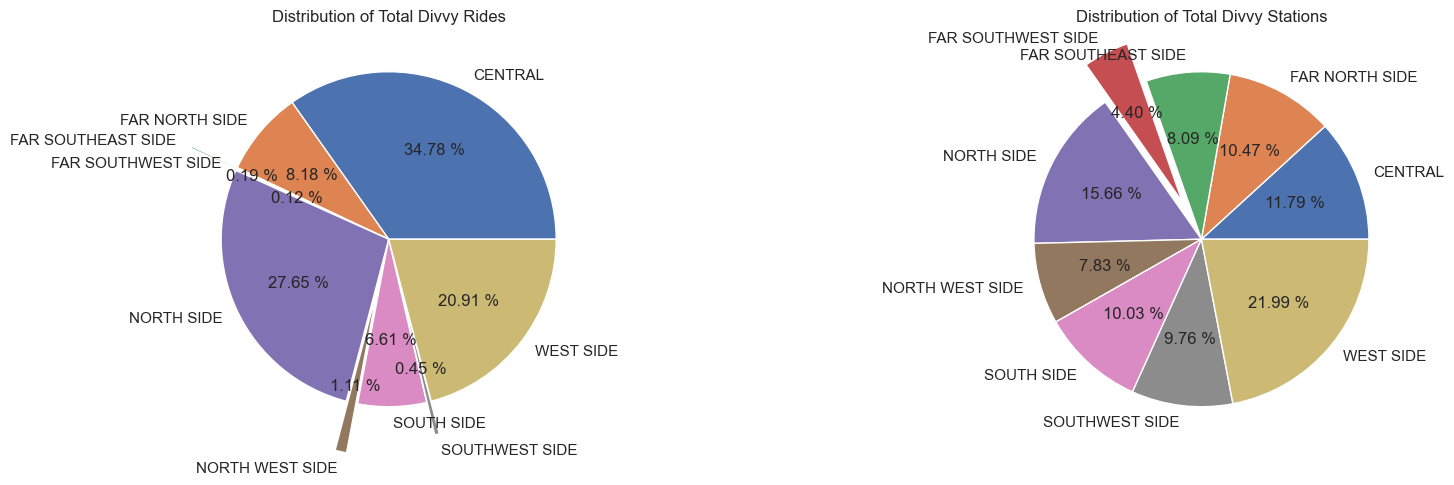

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=False, sharey=False)

explode1 = (0, 0, 0.3, 0, 0, 0.3, 0, 0.2, 0)
axes[0].pie(side_data.Total_Divvy_Rides, labels=side_data.side, explode =explode1, autopct='%.2f %%')
axes[0].set_title("Distribution of Total Divvy Rides")


explode2 = (0, 0, 0, 0.25, 0, 0, 0, 0, 0)
axes[1].pie(side_data.Total_Divvy_Stations, labels=side_data.side, explode =explode2, autopct='%.2f %%')
axes[1].set_title("Distribution of Total Divvy Stations")

plt.tight_layout();

Yet another, even clearer (though the graph is a bit ugly) visualization are these pie charts. The bike rides are not even at all, but bike stations are relatively even. 

#### Potential Conclusion:
This seems to confirm that the Divvy stop placement isn't structured to have more stops in areas with more need, but instead better serve the population overall, mimicking its density. The rides per capita looks similar to the rides per station, meaning that there aren't a strategic placement of bikes -- if there were, the density of rides per station would be pretty even, instead of some being more heavily used and some being used rarely. 

### Question 3: Overall Transit availability not correlated with bike rides?

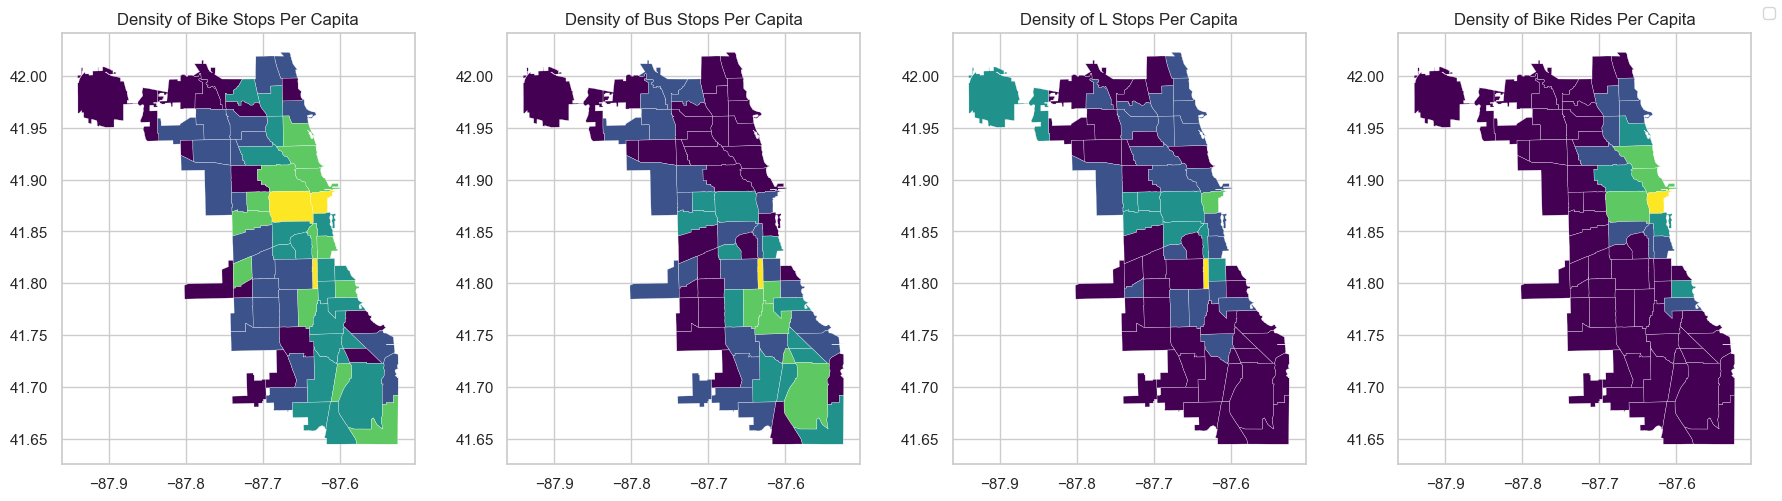

In [74]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=False, sharey=False)

#Bike
chicago_merge.plot(
    column='bike_stops_per_capita', 
    legend=False,
    cmap='viridis',
    scheme='NaturalBreaks',
    ax=axes[0], linewidth=0.2)
axes[0].set_title("Density of Bike Stops Per Capita")

#Bus stops
chicago_merge.plot(
    column='bus_stops_per_capita', 
    legend=False,
    cmap='viridis',
    scheme='NaturalBreaks',
    ax=axes[1], linewidth=0.2)
axes[1].set_title("Density of Bus Stops Per Capita")

#L stops
chicago_merge.plot(
    column='L_stops_per_capita', 
    legend=False,
    cmap='viridis',
    scheme='NaturalBreaks',
    ax=axes[2],linewidth=0.2)
axes[2].set_title("Density of L Stops Per Capita")

#bike rides
chicago_merge.plot(
    column='divvy_per_capita', 
    ax=axes[3],
    legend=False,
    cmap='viridis',
    scheme='NaturalBreaks',linewidth=0.2
)
axes[3].set_title("Density of Bike Rides Per Capita")


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout();

As we can see, the bike rides follows the bike stops trend more visually similarly compared to the other two, though there is a higher concentration overall of bike stops than bike rides. 

#### Potential Conclusion:
The visual comparisons and the correlations seem to suggest that people don’t tend to use Divvy bikes in conjunction with other transi -- if one tended to get off the L and take a bike the last few blocks to work, then we would see a trend between bike rides and L stops. This is not what I expected. Maybe bikes are more used for tourists who stay in one general location, or as a replacement for shorter trips. 

## 2: Transit Availability by Side

First, I will need to scale the different per capita data, since the L is much lower than bikes and buses. 

In [75]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

cols_to_normalize = ['bus_stops_per_capita', 'L_stops_per_capita', 'bike_stops_per_capita']

standard_scaler = MinMaxScaler()
side_data_scaled = side_data.copy()
side_data_scaled[cols_to_normalize] = standard_scaler.fit_transform(side_data_scaled[cols_to_normalize])
side_data_scaled

,side,Total_Population,Total_L_Stops,Total_Bus_Stops,Total_Divvy_Stations,Total_Divvy_Rides,avg_traffic_speed_side,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita
0,CENTRAL,156226.0,25.0,493,134.0,3734447,22.500000,1.000000,0.172462,1.000000,23.904132
1,FAR NORTH SIDE,456323.0,22.0,1241,119.0,878282,24.725000,0.301275,0.000000,0.000000,1.924694
2,FAR SOUTHEAST SIDE,209345.0,3.0,1046,92.0,20394,26.623188,0.089551,0.900420,0.299330,0.097418
3,FAR SOUTHWEST SIDE,175841.0,0.0,656,50.0,12637,24.487500,0.000000,0.399827,0.039480,0.071866
4,NORTH SIDE,296205.0,15.0,844,178.0,2968640,23.917808,0.316455,0.051334,0.569820,10.022248
5,NORTH WEST SIDE,271227.0,3.0,898,89.0,119101,22.896552,0.069120,0.233833,0.112837,0.439119
6,SOUTH SIDE,246744.0,14.0,1295,114.0,709917,27.386667,0.354564,1.000000,0.337108,2.877140
7,SOUTHWEST SIDE,358308.0,8.0,1472,111.0,48670,24.884058,0.139523,0.549129,0.082099,0.135833
8,WEST SIDE,477402.0,34.0,1983,250.0,2244765,22.100000,0.445049,0.567136,0.440383,4.702044


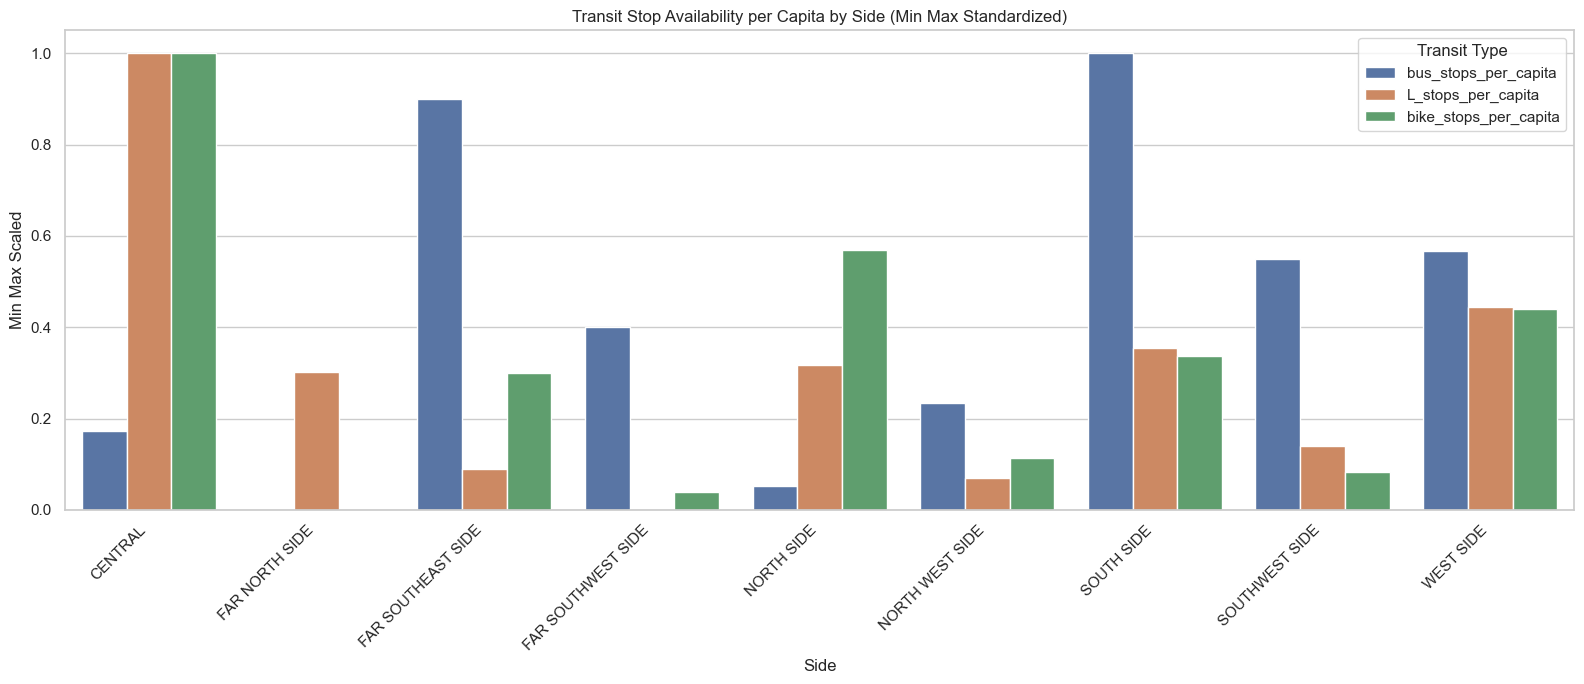

In [76]:
df_long_scaled = side_data_scaled[['side'] + cols_to_normalize].melt(
    id_vars='side',
    value_vars=cols_to_normalize,
    var_name='Transit Type',
    value_name='Min/max Standardized Value'
)


plt.figure(figsize=(16, 7))
sns.barplot(
    x='side',
    y='Min/max Standardized Value',
    hue='Transit Type',
    data=df_long_scaled
)

plt.title('Transit Stop Availability per Capita by Side (Min Max Standardized)')
plt.ylabel('Min Max Scaled')
plt.xlabel('Side')
plt.legend(title='Transit Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout();

By comparing transit availability on a min/max scaler, we can see that the L stop availability and bike station availability go hand in hand, often being similarly placed in the hierarchies in the same communities. However, bus stops follow a different trend, and in some areas with a lot of bus availability, there is less bike and L availability. This may suggest strategic planning which creates a bus grid to better support communities without L access. I also had to use .melt to get this graph to work!

#### Potential Conclusion:
This may suggest that Chicago is built with strategic planning which creates a bus grid to better support communities without L access.

# Conclusions and Recommendations to stakeholder(s)

You may or may not have code to put in this section. Delete this section if it is irrelevant.